# Unified Step Segmentation & Feature Extraction

**Goal:** Segment each recording into individual steps and extract per-step features for ground surface classification.

## Pipeline Overview
```
Raw CSV  →  Preprocess  →  Step Segmentation  →  Feature Extraction  →  Feature DataFrame
```

### Segmentation Strategy
- **Signal:** Total pressure sum across all 12 sensors
- **Step boundaries:** Deep valleys in the total pressure signal — these correspond to the swing phase (foot off/barely on ground)
- Each region between two consecutive deep valleys = one step

### Features Implemented
| # | Feature | Source | What it captures |
|---|---------|--------|------------------|
| 1 | `impact_magnitude` | `accel_y` | Heel strike deceleration shock |
| 2 | `loading_rate` | Pressure sensors | Rate of heel pressure rise |
| 3 | `spectral_energy_ratio` | `accel_y` FFT | High vs low frequency ratio (surface stiffness) |
| 4 | `pressure_entropy` | 12 pressure zones | Distribution irregularity (surface texture) |
| 5 | `step_duration` | Timestamps | Gait timing |
| 6 | `step_to_step_variability` | Meta-feature | Consistency across 4-step windows |

---
**Sensor reference (Stappone manual section 3.3):**
- Heel sensors: `pressure_08`, `pressure_10`, `pressure_11`
- `sole_id = 1` → right foot, `sole_id = 2` → left foot
- Sampling rate: ~62.5 Hz (16ms per sample)
- `accel_y` = vertical axis (Y points toward toe per section 3.4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import entropy as scipy_entropy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('Libraries loaded.')

Libraries loaded.


## 1. Configuration & Constants

In [2]:
# ── File paths ─────────────────────────────────────────────────────────────
DATA_PATHS = {
    'grass':    'data2/grass_dry.csv',
    'brick':    'data2/brick_dry.csv',
    'concrete': 'data2/concrete_dry.csv',
}

SURFACE_COLORS = {
    'grass':    '#4CAF50',
    'brick':    '#E64A19',
    'concrete': '#607D8B',
}

# ── Sensor layout (Stappone manual section 3.3) ────────────────────────────
ALL_PRESSURE   = [f'pressure_{i:02d}' for i in range(1, 13)]
HEEL_SENSORS   = ['pressure_08', 'pressure_10', 'pressure_11']
FORE_SENSORS   = ['pressure_01', 'pressure_02', 'pressure_03']
MID_SENSORS    = ['pressure_04', 'pressure_05', 'pressure_06',
                  'pressure_07', 'pressure_09', 'pressure_12']

# ── Signal processing ──────────────────────────────────────────────────────
FS             = 62.5          # Hz — nominal sampling rate
SMOOTH_WIN     = 11            # Savitzky-Golay window (samples)
SMOOTH_POLY    = 2             # Savitzky-Golay polynomial order

# ── Step segmentation ─────────────────────────────────────────────────────
# Swing-phase valleys must be below this fraction of the signal range
SWING_VALLEY_FRAC  = 0.40     # 40% of (max-min) above min = valley threshold
MIN_STEP_DIST_S    = 0.25     # minimum step duration in seconds
VALLEY_PROMINENCE  = 200      # min prominence for a valley to count

# ── Feature parameters ────────────────────────────────────────────────────
# Loading rate: heel sensor window around the first pressure peak inside step
HILL_WINDOW        = 12       # samples to search for heel peak after contact
MIN_PRESSURE_RISE  = 5        # min ADC units of pressure rise (reject noise)

# Impact detection: look for accel_y trough in first portion of step
IMPACT_SEARCH_FRAC = 0.5      # search in first 50% of step samples
IMPACT_MIN_ABS     = 500      # minimum |accel_y| to count as real impact

# Spectral energy ratio
FREQ_LOW_HZ        = (0,  10)  # low-frequency band
FREQ_HIGH_HZ       = (30, 50)  # high-frequency band (surface vibration)

# Step-to-step variability window
VAR_WINDOW         = 4         # number of consecutive steps for std computation

print('Configuration complete.')
print(f'Sampling rate: {FS} Hz | Smooth window: {SMOOTH_WIN} samples')
print(f'Min step distance: {MIN_STEP_DIST_S}s = {int(MIN_STEP_DIST_S*FS)} samples')

Configuration complete.
Sampling rate: 62.5 Hz | Smooth window: 11 samples
Min step distance: 0.25s = 15 samples


## 2. Data Loading & Preprocessing

In [3]:
def load_and_preprocess(csv_path, surface_label):
    """
    Load a raw CSV, drop corrupt rows, compute derived columns.
    Returns a dict keyed by sole_id.
    """
    df = pd.read_csv(csv_path)
    before = len(df)
    df = df[df['corrupt'] == 0].copy()
    dropped = before - len(df)

    result = {}
    for sid in sorted(df['sole_id'].unique()):
        sub = (df[df['sole_id'] == sid]
               .sort_values('timestamp')
               .reset_index(drop=True))

        # Time in seconds from recording start
        sub['time_s'] = (sub['timestamp'] - sub['timestamp'].iloc[0]) / 1000.0

        # Pressure sums
        sub['total_pressure'] = sub[ALL_PRESSURE].sum(axis=1)
        sub['heel_pressure']  = sub[HEEL_SENSORS].sum(axis=1)
        sub['fore_pressure']  = sub[FORE_SENSORS].sum(axis=1)

        # Smoothed total pressure for segmentation
        n = len(sub)
        win = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
        if win % 2 == 0: win -= 1
        if win <= SMOOTH_POLY: win = SMOOTH_POLY + 1 + (SMOOTH_POLY % 2 == 0)
        sub['total_pressure_smooth'] = savgol_filter(
            sub['total_pressure'].values, win, SMOOTH_POLY)

        result[sid] = sub

    foot_map = {1: 'right', 2: 'left'}
    for sid, sub in result.items():
        dur = sub['time_s'].iloc[-1]
        print(f'  {surface_label} | sole {sid} ({foot_map.get(sid,"?")}): '
              f'{len(sub):,} rows, {dur:.1f}s  [{dropped} corrupt dropped]')
    return result


# Load all surfaces
raw = {}
for surface, path in DATA_PATHS.items():
    print(f'Loading {surface}...')
    raw[surface] = load_and_preprocess(path, surface)

print('\nAll data loaded.')

Loading grass...
  grass | sole 1 (right): 1,489 rows, 25.2s  [0 corrupt dropped]
  grass | sole 2 (left): 1,490 rows, 25.2s  [0 corrupt dropped]
Loading brick...
  brick | sole 1 (right): 1,483 rows, 25.4s  [0 corrupt dropped]
  brick | sole 2 (left): 1,457 rows, 24.6s  [0 corrupt dropped]
Loading concrete...
  concrete | sole 1 (right): 2,163 rows, 37.1s  [0 corrupt dropped]
  concrete | sole 2 (left): 2,186 rows, 36.8s  [0 corrupt dropped]

All data loaded.


## 3. Step Segmentation

**Method:** Detect the "swing phase" of each step as a deep valley in the smoothed total-pressure signal. Between each pair of consecutive deep valleys = one step cycle.

```
total_pressure
    ▲
    │   ╭─╮   ╭─╮   ╭─╮
    │  ╱   ╲ ╱   ╲ ╱   ╲
    │ ╱     ╲     ╲     ╲
    │╱     ▼ ╲   ▼ ╲   ▼ ╲
    └──────────────────────▶ time
           ▲           ▲
       deep valleys = step boundaries
```

In [4]:
def segment_steps(sub):
    """
    Find step boundaries from deep valleys in the smoothed total pressure.

    Returns
    -------
    boundaries : list of int
        Sample indices of swing-phase valley centres (step boundaries).
    steps : list of dict
        Each dict has keys: start_idx, end_idx, start_t, end_t, duration_s
    """
    sig = sub['total_pressure_smooth'].values
    n   = len(sig)

    # Threshold for a "deep" valley (swing phase)
    p_min = sig.min()
    p_max = sig.max()
    swing_threshold = p_min + SWING_VALLEY_FRAC * (p_max - p_min)

    min_dist_samples = max(5, int(MIN_STEP_DIST_S * FS))

    # Find deep valleys: inverted peaks below threshold
    valleys, _ = find_peaks(
        -sig,
        height   = -swing_threshold,   # only valleys below threshold
        distance = min_dist_samples,
        prominence = VALLEY_PROMINENCE,
    )

    # Build step windows between consecutive valleys
    steps = []
    for i in range(len(valleys) - 1):
        s_idx = valleys[i]
        e_idx = valleys[i + 1]
        s_t   = sub['time_s'].iloc[s_idx]
        e_t   = sub['time_s'].iloc[e_idx]
        dur   = e_t - s_t
        if dur < MIN_STEP_DIST_S:
            continue
        steps.append({
            'start_idx':  s_idx,
            'end_idx':    e_idx,
            'start_t':    s_t,
            'end_t':      e_t,
            'duration_s': dur,
        })

    return valleys, steps


# Run segmentation on all surfaces and soles
segmentation = {}  # segmentation[surface][sole_id] = (valleys, steps)

print('Step segmentation results:')
print(f'{"Surface":<12} {"Sole":>6} {"Steps":>7} {"Cadence (spm)":>15} {"Avg dur (s)":>12}')
print('-' * 56)

for surface, soles in raw.items():
    segmentation[surface] = {}
    for sid, sub in soles.items():
        valleys, steps = segment_steps(sub)
        segmentation[surface][sid] = (valleys, steps)
        n_steps   = len(steps)
        if n_steps > 1:
            avg_dur  = np.mean([s['duration_s'] for s in steps])
            cadence  = 60.0 / avg_dur
        else:
            avg_dur, cadence = float('nan'), float('nan')
        print(f'{surface:<12} {sid:>6} {n_steps:>7} {cadence:>15.1f} {avg_dur:>12.3f}')

Step segmentation results:
Surface        Sole   Steps   Cadence (spm)  Avg dur (s)
--------------------------------------------------------
grass             1      20            51.2        1.171
grass             2      21            51.1        1.173
brick             1      21            53.5        1.122
brick             2      21            53.5        1.121
concrete          1      29            53.6        1.120
concrete          2      29            53.6        1.119


## 4. Visualise Segmentation — Sanity Check

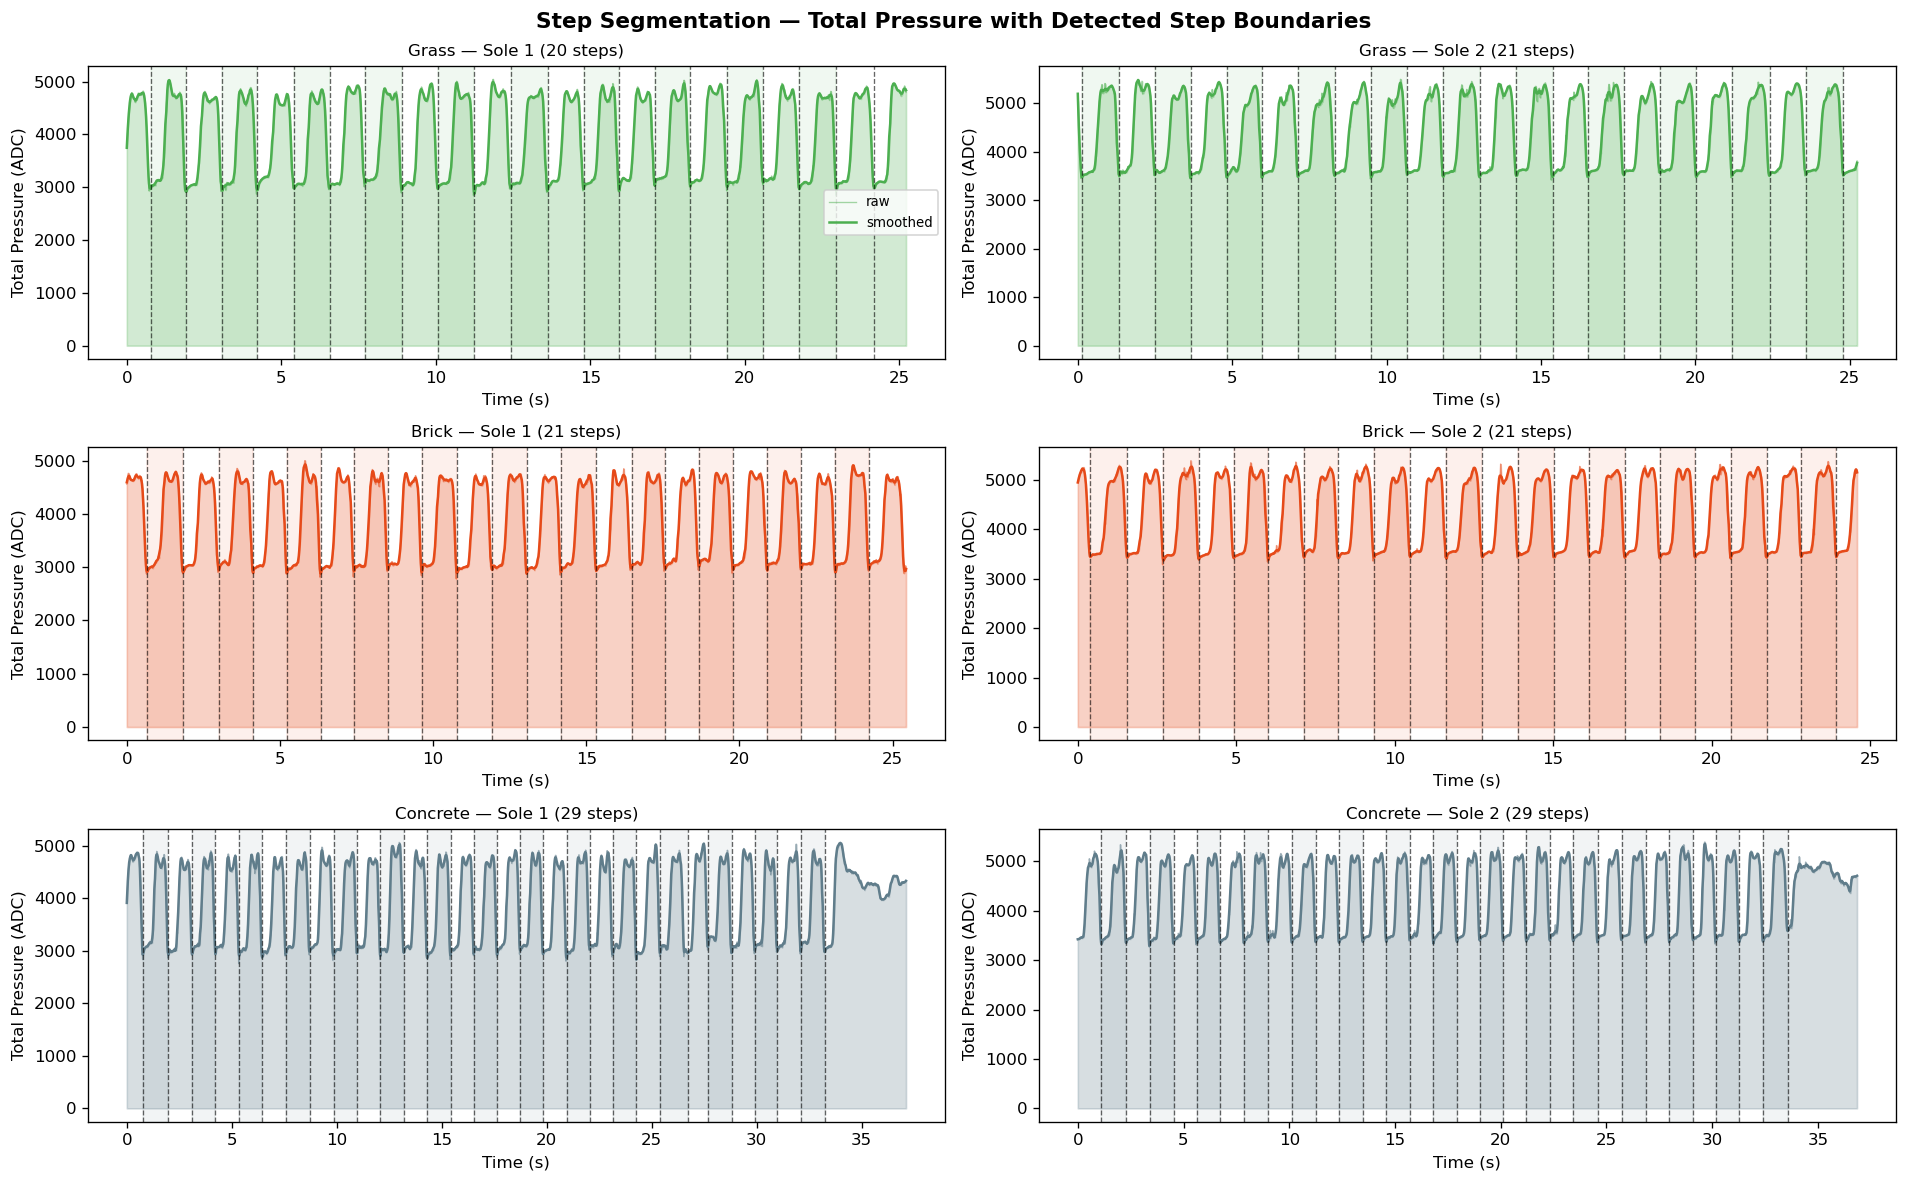

Saved → segmentation_overview.png


In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharey=False)
fig.suptitle('Step Segmentation — Total Pressure with Detected Step Boundaries',
             fontsize=13, fontweight='bold')

for row_idx, surface in enumerate(['grass', 'brick', 'concrete']):
    color = SURFACE_COLORS[surface]
    for col_idx, sid in enumerate([1, 2]):
        ax  = axes[row_idx, col_idx]
        sub = raw[surface][sid]
        valleys, steps = segmentation[surface][sid]

        t   = sub['time_s'].values
        p   = sub['total_pressure'].values
        ps  = sub['total_pressure_smooth'].values

        ax.fill_between(t, p, alpha=0.25, color=color)
        ax.plot(t, p,  color=color, alpha=0.5, lw=0.8, label='raw')
        ax.plot(t, ps, color=color, lw=1.5, label='smoothed')

        # Step boundaries
        for v in valleys:
            ax.axvline(t[v], color='black', lw=0.8, alpha=0.6, ls='--')

        # Shade every other step
        for k, step in enumerate(steps):
            if k % 2 == 0:
                ax.axvspan(step['start_t'], step['end_t'],
                           alpha=0.08, color=color)

        ax.set_title(f'{surface.capitalize()} — Sole {sid} ({len(steps)} steps)',
                     fontsize=10)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Total Pressure (ADC)')
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('segmentation_overview.png', bbox_inches='tight')
plt.show()
print('Saved → segmentation_overview.png')

## 5. Single-Step Deep Dive — Signal Anatomy

Zoom into 3 consecutive steps to understand the signal structure inside each step window.

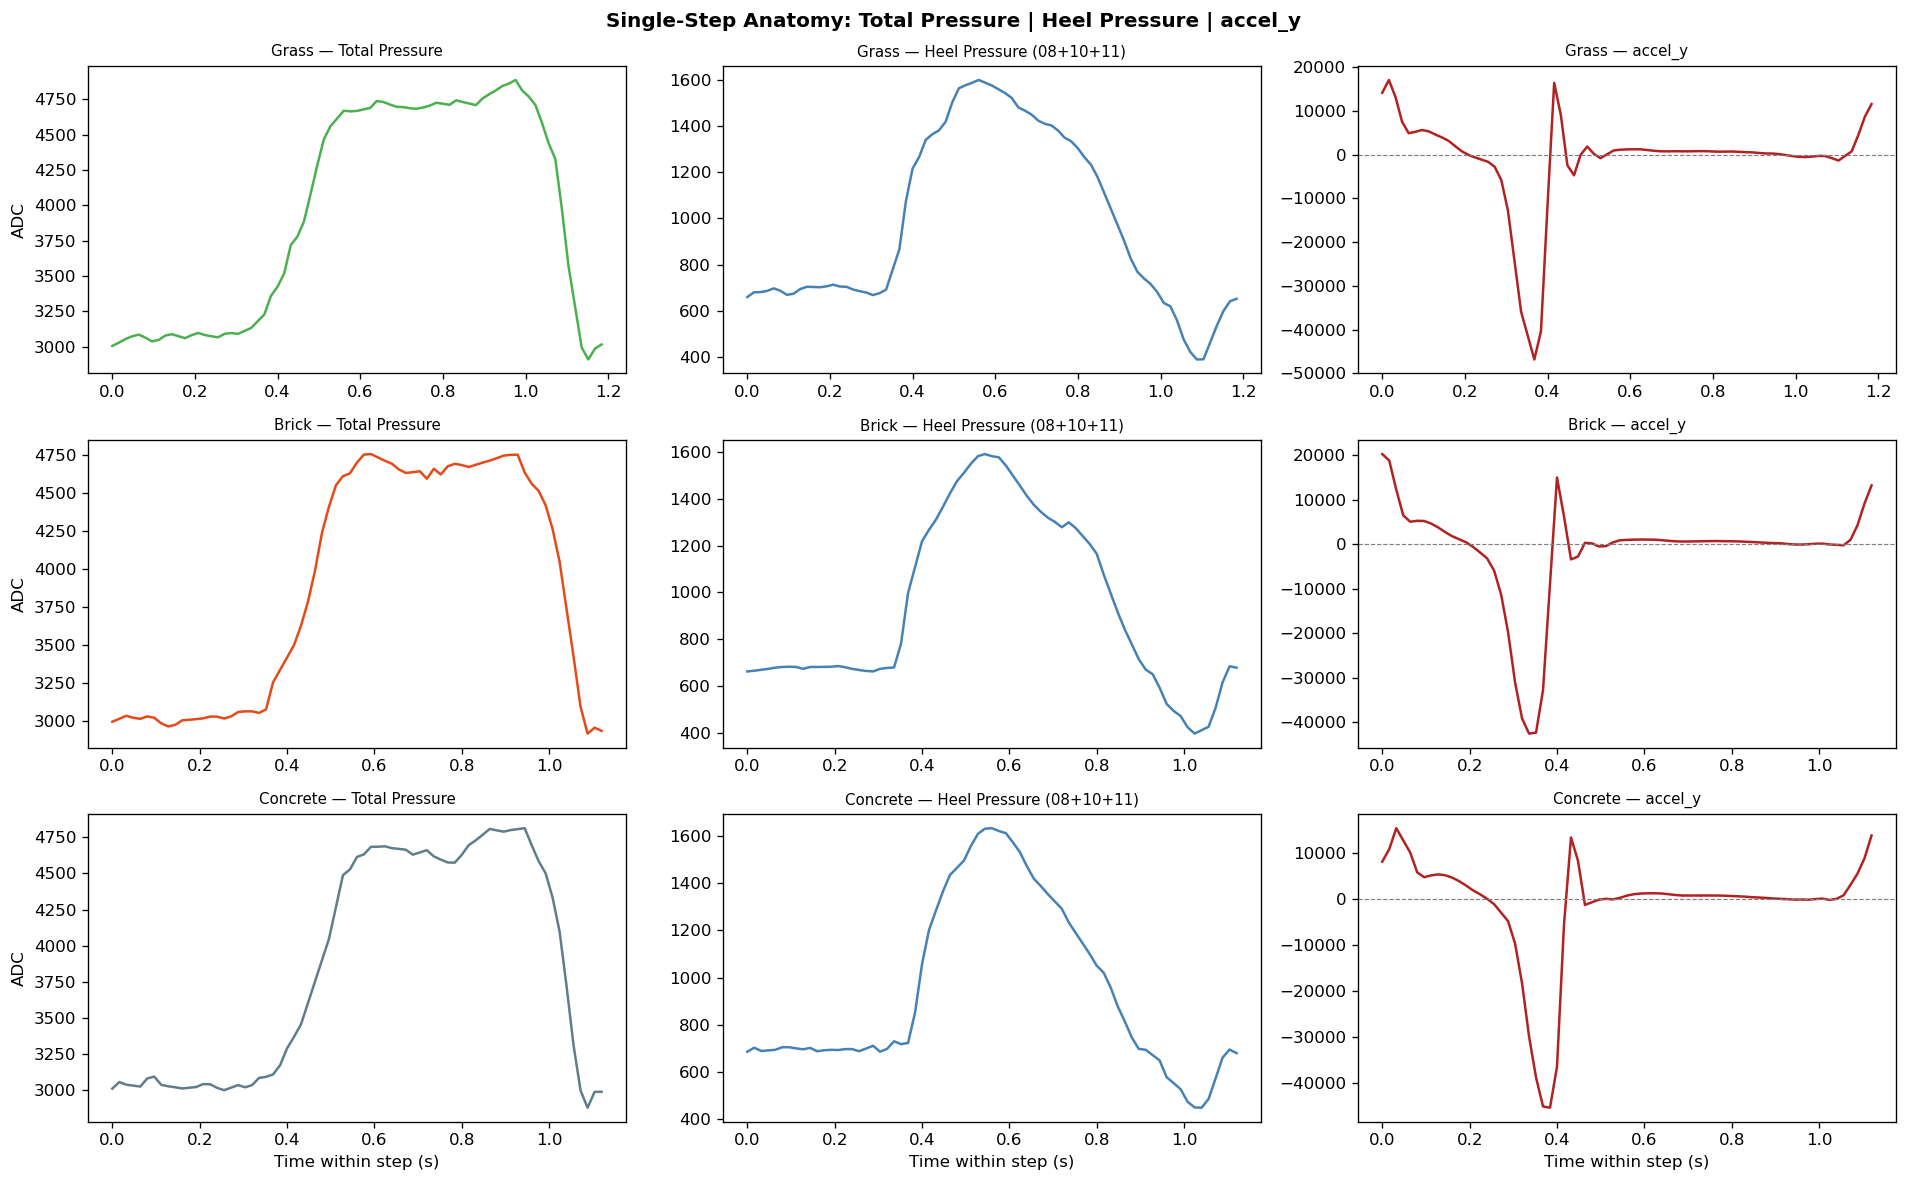

Saved → step_anatomy.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Single-Step Anatomy: Total Pressure | Heel Pressure | accel_y',
             fontsize=12, fontweight='bold')

for row_idx, surface in enumerate(['grass', 'brick', 'concrete']):
    sub  = raw[surface][1]   # right sole
    _, steps = segmentation[surface][1]
    color = SURFACE_COLORS[surface]

    # Pick 3 steps from the middle of the recording
    mid = len(steps) // 2
    step = steps[mid]
    sl   = slice(step['start_idx'], step['end_idx'] + 1)
    t_w  = sub['time_s'].values[sl] - sub['time_s'].values[step['start_idx']]

    axes[row_idx, 0].plot(t_w, sub['total_pressure'].values[sl], color=color, lw=1.5)
    axes[row_idx, 0].set_title(f'{surface.capitalize()} — Total Pressure', fontsize=9)
    axes[row_idx, 0].set_ylabel('ADC')

    axes[row_idx, 1].plot(t_w, sub['heel_pressure'].values[sl], color='steelblue', lw=1.5)
    axes[row_idx, 1].set_title(f'{surface.capitalize()} — Heel Pressure (08+10+11)', fontsize=9)

    axes[row_idx, 2].plot(t_w, sub['accel_y'].values[sl], color='firebrick', lw=1.5)
    axes[row_idx, 2].axhline(0, color='gray', lw=0.7, ls='--')
    axes[row_idx, 2].set_title(f'{surface.capitalize()} — accel_y', fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel('Time within step (s)')

plt.tight_layout()
plt.savefig('step_anatomy.png', bbox_inches='tight')
plt.show()
print('Saved → step_anatomy.png')

## 6. Feature Extraction Functions

Each function receives a **step-window slice** of the DataFrame and returns a scalar feature.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 1: Accelerometer Impact Magnitude at Heel Strike
# ─────────────────────────────────────────────────────────────────────────────
def feature_impact_magnitude(step_df):
    """
    Peak |accel_y| in the first IMPACT_SEARCH_FRAC of the step.
    Negative accel_y spike = deceleration shock at heel contact.

    Returns: float (ADC units)
    """
    n       = len(step_df)
    search  = max(3, int(n * IMPACT_SEARCH_FRAC))
    ay      = step_df['accel_y'].values[:search]
    impact  = float(np.abs(ay).max())
    return impact if impact >= IMPACT_MIN_ABS else np.nan


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 2: Loading Rate
# ─────────────────────────────────────────────────────────────────────────────
def feature_loading_rate(step_df):
    """
    Rate of heel pressure rise from local minimum to first local peak.
    = pressure_rise / time_to_peak   (ADC units / second)

    Returns: float or np.nan if no clean ramp found
    """
    t  = step_df['time_s'].values
    hp = step_df['heel_pressure'].values

    if len(hp) < 4:
        return np.nan

    # Contact point: minimum in first third of step
    search_end = max(4, len(hp) // 3)
    c_local    = int(np.argmin(hp[:search_end]))

    # Heel-strike peak: first local max after contact
    seg       = hp[c_local : c_local + HILL_WINDOW + 1]
    lp, _     = find_peaks(seg, prominence=1)
    h_local   = lp[0] if len(lp) else int(np.argmax(seg[1:])) + 1
    h_idx     = c_local + h_local

    dt = t[h_idx] - t[c_local]
    dp = hp[h_idx] - hp[c_local]

    if dt <= 0 or dp < MIN_PRESSURE_RISE:
        return np.nan

    return float(dp / dt)


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 3: Spectral Energy Ratio (High / Low Frequency)
# ─────────────────────────────────────────────────────────────────────────────
def feature_spectral_energy_ratio(step_df):
    """
    Ratio of high-frequency energy (30–50 Hz) to low-frequency energy (0–10 Hz)
    in the accel_y signal during the step.

    Hard surfaces transmit more high-frequency vibration → higher ratio.

    Returns: float or np.nan if step too short for FFT
    """
    ay = step_df['accel_y'].values
    n  = len(ay)

    if n < 8:
        return np.nan

    # Zero-mean and apply Hann window
    ay   = ay - ay.mean()
    win  = np.hanning(n)
    spec = np.abs(np.fft.rfft(ay * win)) ** 2
    freq = np.fft.rfftfreq(n, d=1.0 / FS)

    low_mask  = (freq >= FREQ_LOW_HZ[0])  & (freq <= FREQ_LOW_HZ[1])
    high_mask = (freq >= FREQ_HIGH_HZ[0]) & (freq <= FREQ_HIGH_HZ[1])

    e_low  = spec[low_mask].sum()  + 1e-10   # avoid div-by-zero
    e_high = spec[high_mask].sum() + 1e-10

    return float(e_high / e_low)


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 4: Pressure Distribution Entropy (Mid-Stance)
# ─────────────────────────────────────────────────────────────────────────────
def feature_pressure_entropy(step_df):
    """
    Shannon entropy of the mean pressure distribution across all 12 zones
    during the mid-stance portion of the step (middle 40%).

    Irregular/textured surfaces (gravel, brick) → high entropy.
    Smooth surfaces (concrete) → low, consistent entropy.

    Returns: float
    """
    n   = len(step_df)
    s   = max(1, int(n * 0.30))
    e   = max(s + 1, int(n * 0.70))
    mid = step_df.iloc[s:e]

    zone_means = mid[ALL_PRESSURE].mean(axis=0).values
    zone_means = np.maximum(zone_means, 1e-10)    # ensure positive
    probs      = zone_means / zone_means.sum()
    return float(scipy_entropy(probs))


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE 5: Step Duration
# ─────────────────────────────────────────────────────────────────────────────
def feature_step_duration(step):
    """
    Duration of the step window in seconds.
    Passed the step dict (not the DataFrame slice).
    """
    return float(step['duration_s'])


# ─────────────────────────────────────────────────────────────────────────────
# BONUS: Extra pressure features (forefoot/heel ratio, max zone)
# ─────────────────────────────────────────────────────────────────────────────
def feature_fore_heel_ratio(step_df):
    """
    Mean forefoot pressure / mean heel pressure over the full step.
    Captures weight transfer pattern.
    """
    fore = step_df[FORE_SENSORS].values.mean()
    heel = step_df[HEEL_SENSORS].values.mean() + 1e-10
    return float(fore / heel)


def feature_peak_total_pressure(step_df):
    """Maximum total pressure within the step."""
    return float(step_df['total_pressure'].max())


def feature_heel_impact_pressure(step_df):
    """Peak heel pressure within the step."""
    return float(step_df['heel_pressure'].max())


print('Feature functions defined:')
print('  1. impact_magnitude      (accel_y)')
print('  2. loading_rate          (heel pressure rise)')
print('  3. spectral_energy_ratio (accel_y FFT)')
print('  4. pressure_entropy      (12-zone distribution)')
print('  5. step_duration         (timing)')
print('  6. fore_heel_ratio       (weight transfer)')
print('  7. peak_total_pressure   (max load)')
print('  8. heel_impact_pressure  (heel max load)')

Feature functions defined:
  1. impact_magnitude      (accel_y)
  2. loading_rate          (heel pressure rise)
  3. spectral_energy_ratio (accel_y FFT)
  4. pressure_entropy      (12-zone distribution)
  5. step_duration         (timing)
  6. fore_heel_ratio       (weight transfer)
  7. peak_total_pressure   (max load)
  8. heel_impact_pressure  (heel max load)


## 7. Run Feature Extraction Across All Steps

In [8]:
def extract_all_features(sub, steps, surface, sole_id):
    """
    For each detected step, extract all features.
    Returns a list of dicts (one per step).
    """
    records = []
    for step_idx, step in enumerate(steps):
        sl       = slice(step['start_idx'], step['end_idx'] + 1)
        step_df  = sub.iloc[sl].copy()

        if len(step_df) < 4:
            continue

        rec = {
            'surface':              surface,
            'sole_id':              sole_id,
            'step_idx':             step_idx,
            'start_t':              step['start_t'],
            'end_t':                step['end_t'],
            # ── Features ──
            'impact_magnitude':      feature_impact_magnitude(step_df),
            'loading_rate':          feature_loading_rate(step_df),
            'spectral_energy_ratio': feature_spectral_energy_ratio(step_df),
            'pressure_entropy':      feature_pressure_entropy(step_df),
            'step_duration':         feature_step_duration(step),
            'fore_heel_ratio':       feature_fore_heel_ratio(step_df),
            'peak_total_pressure':   feature_peak_total_pressure(step_df),
            'heel_impact_pressure':  feature_heel_impact_pressure(step_df),
        }
        records.append(rec)
    return records


# Extract for all surfaces and soles
all_records = []
for surface, soles in raw.items():
    for sid, sub in soles.items():
        _, steps = segmentation[surface][sid]
        recs = extract_all_features(sub, steps, surface, sid)
        all_records.extend(recs)
        print(f'{surface} sole {sid}: {len(recs)} steps extracted')

features_df = pd.DataFrame(all_records)
print(f'\nTotal step records: {len(features_df)}')
print(f'Columns: {list(features_df.columns)}')

grass sole 1: 20 steps extracted
grass sole 2: 21 steps extracted
brick sole 1: 21 steps extracted
brick sole 2: 21 steps extracted
concrete sole 1: 29 steps extracted
concrete sole 2: 29 steps extracted

Total step records: 141
Columns: ['surface', 'sole_id', 'step_idx', 'start_t', 'end_t', 'impact_magnitude', 'loading_rate', 'spectral_energy_ratio', 'pressure_entropy', 'step_duration', 'fore_heel_ratio', 'peak_total_pressure', 'heel_impact_pressure']


## 8. Feature 6: Step-to-Step Variability (Meta-Feature)

Computed as a rolling standard deviation over `VAR_WINDOW` consecutive steps. This captures surface *regularity* — irregular surfaces like gravel increase variability.

In [9]:
def add_step_variability(df, window=VAR_WINDOW):
    """
    Add rolling std of key features over VAR_WINDOW consecutive steps,
    computed separately per (surface, sole_id) group.
    """
    target_cols = ['impact_magnitude', 'loading_rate',
                   'spectral_energy_ratio', 'pressure_entropy']

    df = df.copy()
    for col in target_cols:
        df[f'{col}_var'] = np.nan

    for (surface, sid), group in df.groupby(['surface', 'sole_id']):
        idx = group.index
        for col in target_cols:
            rolling_std = (group[col]
                           .rolling(window, min_periods=2)
                           .std()
                           .values)
            df.loc[idx, f'{col}_var'] = rolling_std

    return df


features_df = add_step_variability(features_df)

print('Step-to-step variability columns added:')
var_cols = [c for c in features_df.columns if c.endswith('_var')]
print(' ', var_cols)
print()
print(features_df[['surface', 'sole_id', 'step_idx',
                    'impact_magnitude', 'loading_rate',
                    'spectral_energy_ratio', 'pressure_entropy']]
      .head(10).to_string(index=False))

Step-to-step variability columns added:
  ['impact_magnitude_var', 'loading_rate_var', 'spectral_energy_ratio_var', 'pressure_entropy_var']

surface  sole_id  step_idx  impact_magnitude  loading_rate  spectral_energy_ratio  pressure_entropy
  grass        1         0           42191.0    250.000000               0.000043          2.463774
  grass        1         1           40100.0    562.500000               0.000008          2.455040
  grass        1         2           44158.0    864.583333               0.000080          2.458823
  grass        1         3           39511.0    687.500000               0.000025          2.460403
  grass        1         4           43838.0    406.250000               0.000007          2.459884
  grass        1         5           43574.0   2000.000000               0.000153          2.464285
  grass        1         6           40162.0    546.875000               0.000073          2.457071
  grass        1         7           41794.0    437.500000 

## 9. Summary Statistics per Surface

In [10]:
feature_cols = [
    'impact_magnitude', 'loading_rate', 'spectral_energy_ratio',
    'pressure_entropy', 'step_duration', 'fore_heel_ratio',
    'peak_total_pressure', 'heel_impact_pressure'
]

summary = (
    features_df
    .groupby('surface')[feature_cols]
    .agg(['mean', 'std', 'median', 'count'])
    .round(2)
)

print('=== Per-Surface Feature Summary ===')
print(summary.to_string())

# Flat summary for readability
flat_summary = features_df.groupby('surface')[feature_cols].mean().round(2)
print('\n=== Mean Feature Values by Surface ===')
print(flat_summary.to_string())

=== Per-Surface Feature Summary ===
         impact_magnitude                         loading_rate                        spectral_energy_ratio                   pressure_entropy                   step_duration                    fore_heel_ratio                    peak_total_pressure                       heel_impact_pressure                      
                     mean      std   median count         mean      std  median count                  mean  std median count             mean  std median count          mean   std median count            mean   std median count                mean     std  median count                 mean     std  median count
surface                                                                                                                                                                                                                                                                                                                  
brick            45359

## 10. Feature Comparison Visualisation

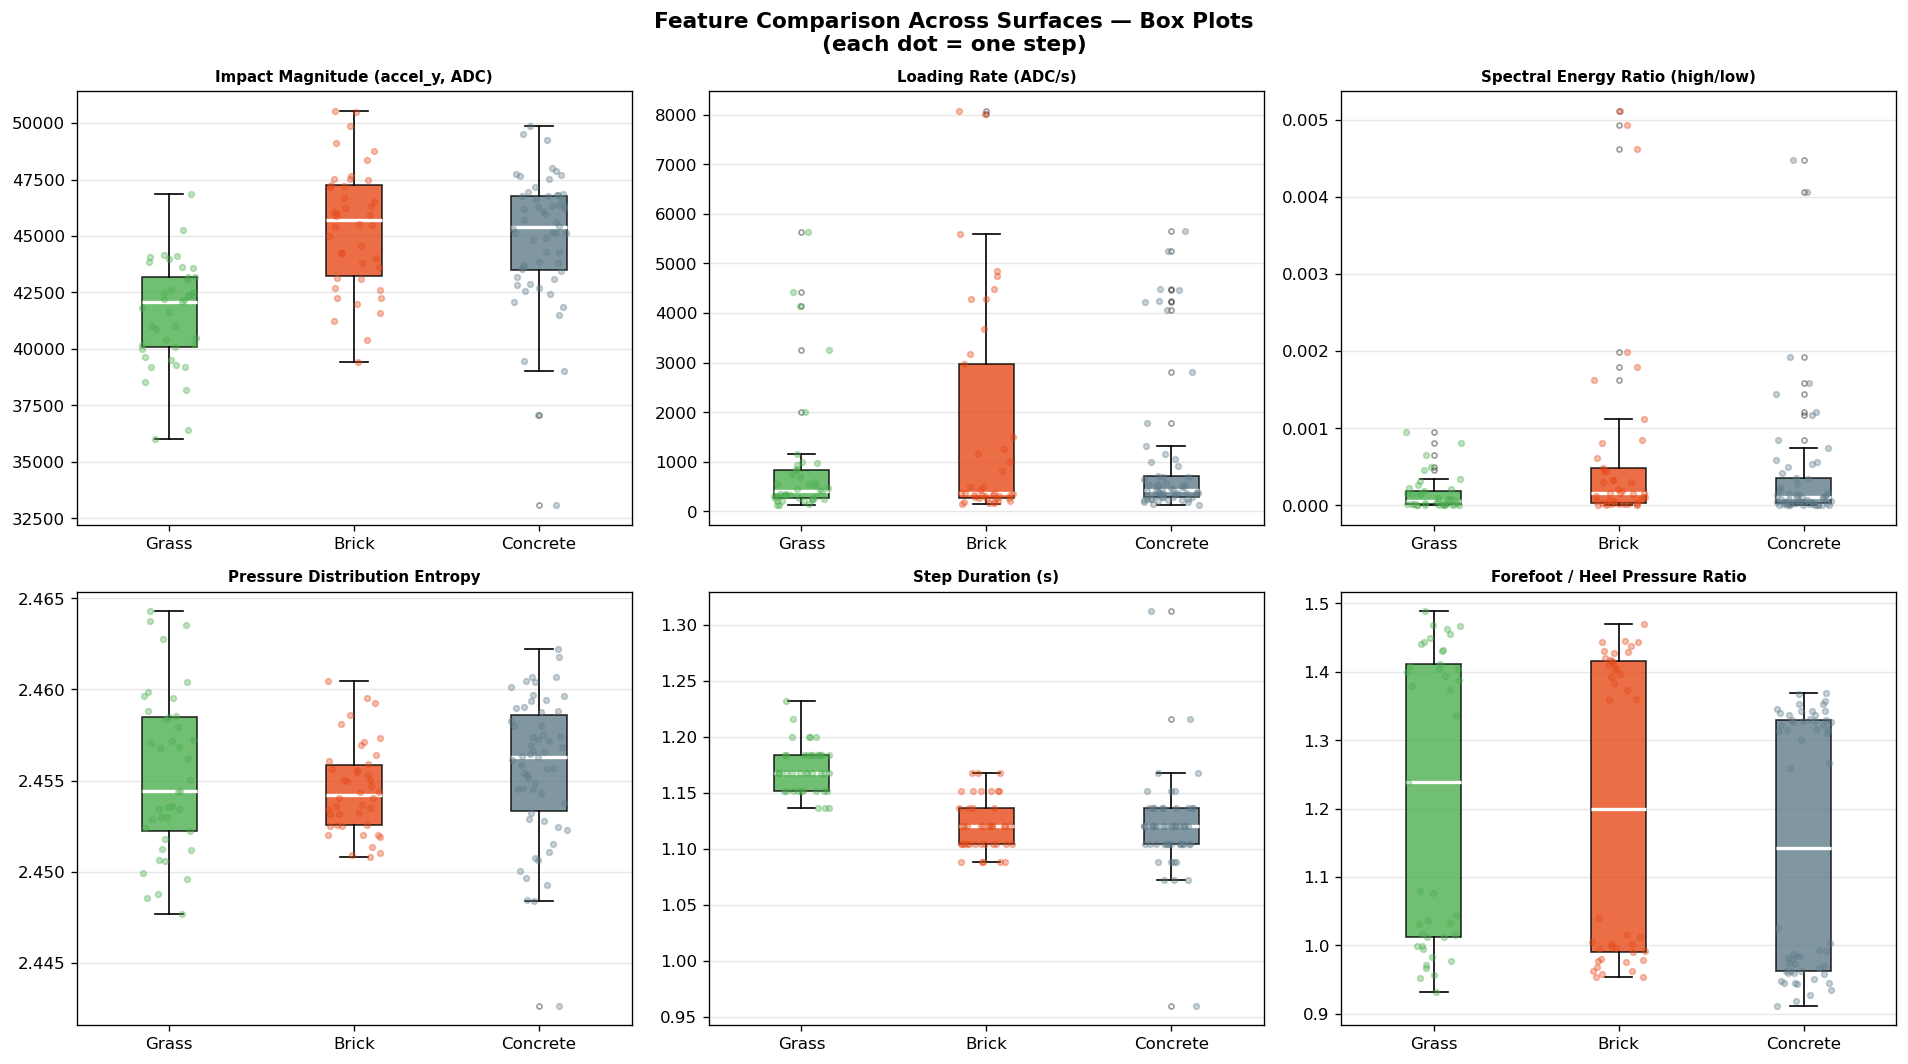

Saved → feature_comparison.png


In [11]:
plot_features = [
    ('impact_magnitude',      'Impact Magnitude (accel_y, ADC)'),
    ('loading_rate',          'Loading Rate (ADC/s)'),
    ('spectral_energy_ratio', 'Spectral Energy Ratio (high/low)'),
    ('pressure_entropy',      'Pressure Distribution Entropy'),
    ('step_duration',         'Step Duration (s)'),
    ('fore_heel_ratio',       'Forefoot / Heel Pressure Ratio'),
]

surfaces_ord = ['grass', 'brick', 'concrete']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Comparison Across Surfaces — Box Plots\n(each dot = one step)',
             fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes.flat, plot_features):
    data = [features_df[features_df['surface'] == s][col].dropna().values
            for s in surfaces_ord]

    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='.', alpha=0.4))
    for patch, s in zip(bp['boxes'], surfaces_ord):
        patch.set_facecolor(SURFACE_COLORS[s])
        patch.set_alpha(0.8)

    # Strip plot overlay
    for k, (s, d) in enumerate(zip(surfaces_ord, data)):
        jitter = np.random.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(k + 1 + jitter, d, color=SURFACE_COLORS[s],
                   alpha=0.35, s=12, zorder=3)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([s.capitalize() for s in surfaces_ord])
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_comparison.png', bbox_inches='tight')
plt.show()
print('Saved → feature_comparison.png')

## 11. Feature Correlation Matrix

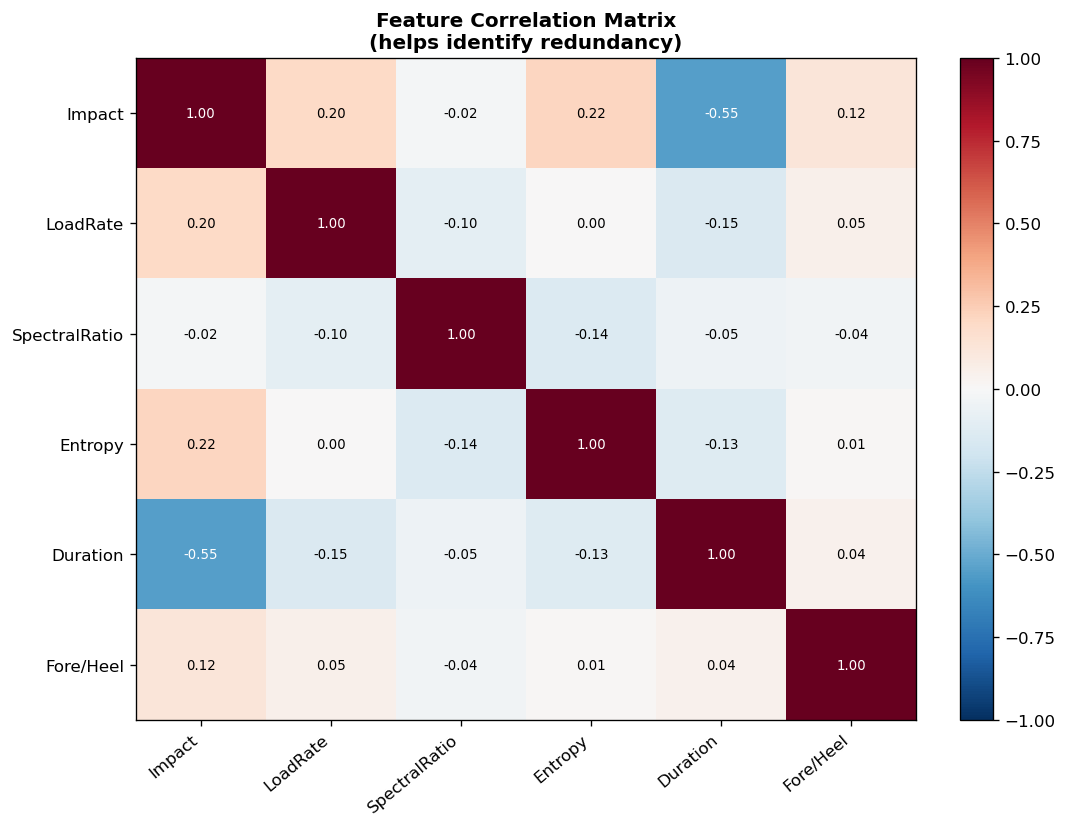

Saved → feature_correlation.png

High correlation = features may be redundant.
Low/negative correlation = features capture different physics.


In [12]:
corr_cols = [
    'impact_magnitude', 'loading_rate', 'spectral_energy_ratio',
    'pressure_entropy', 'step_duration', 'fore_heel_ratio'
]

corr = features_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046)

short_labels = ['Impact', 'LoadRate', 'SpectralRatio',
                'Entropy', 'Duration', 'Fore/Heel']
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(short_labels, rotation=40, ha='right')
ax.set_yticklabels(short_labels)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8,
                color='white' if abs(val) > 0.5 else 'black')

ax.set_title('Feature Correlation Matrix\n(helps identify redundancy)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()
print('Saved → feature_correlation.png')
print('\nHigh correlation = features may be redundant.')
print('Low/negative correlation = features capture different physics.')

## 12. Export Feature Dataset

In [13]:
# Per-step features (one row per step)
features_df.to_csv('step_features_per_step.csv', index=False)
print(f'Saved → step_features_per_step.csv  ({len(features_df)} rows)')

# Aggregated trial-level features (one row per surface × sole)
agg_cols = feature_cols
trial_features = (
    features_df
    .groupby(['surface', 'sole_id'])[agg_cols]
    .agg(['mean', 'std', 'median',
          lambda x: x.quantile(0.75)])
    .round(3)
)
trial_features.columns = ['_'.join(c) if c[1] != '<lambda_0>' else f'{c[0]}_p75'
                           for c in trial_features.columns]
trial_features = trial_features.reset_index()
trial_features.to_csv('step_features_trial_level.csv', index=False)
print(f'Saved → step_features_trial_level.csv  ({len(trial_features)} rows)')

print('\nSample trial-level features:')
print(trial_features[['surface', 'sole_id',
                       'impact_magnitude_mean',
                       'loading_rate_mean',
                       'spectral_energy_ratio_mean',
                       'pressure_entropy_mean']].to_string(index=False))

Saved → step_features_per_step.csv  (141 rows)
Saved → step_features_trial_level.csv  (6 rows)

Sample trial-level features:
 surface  sole_id  impact_magnitude_mean  loading_rate_mean  spectral_energy_ratio_mean  pressure_entropy_mean
   brick        1              44696.238           1205.124                       0.001                  2.455
   brick        2              46023.095           2102.941                       0.001                  2.454
concrete        1              43751.069           1371.151                       0.001                  2.454
concrete        2              46007.690            669.680                       0.000                  2.458
   grass        1              42281.900            626.302                       0.000                  2.457
   grass        2              40854.286           1111.343                       0.000                  2.453


## 13. Quick Discriminability Check — 2D Feature Scatter

Visualise the most promising feature pairs. Good separability here = good input for Random Forest.

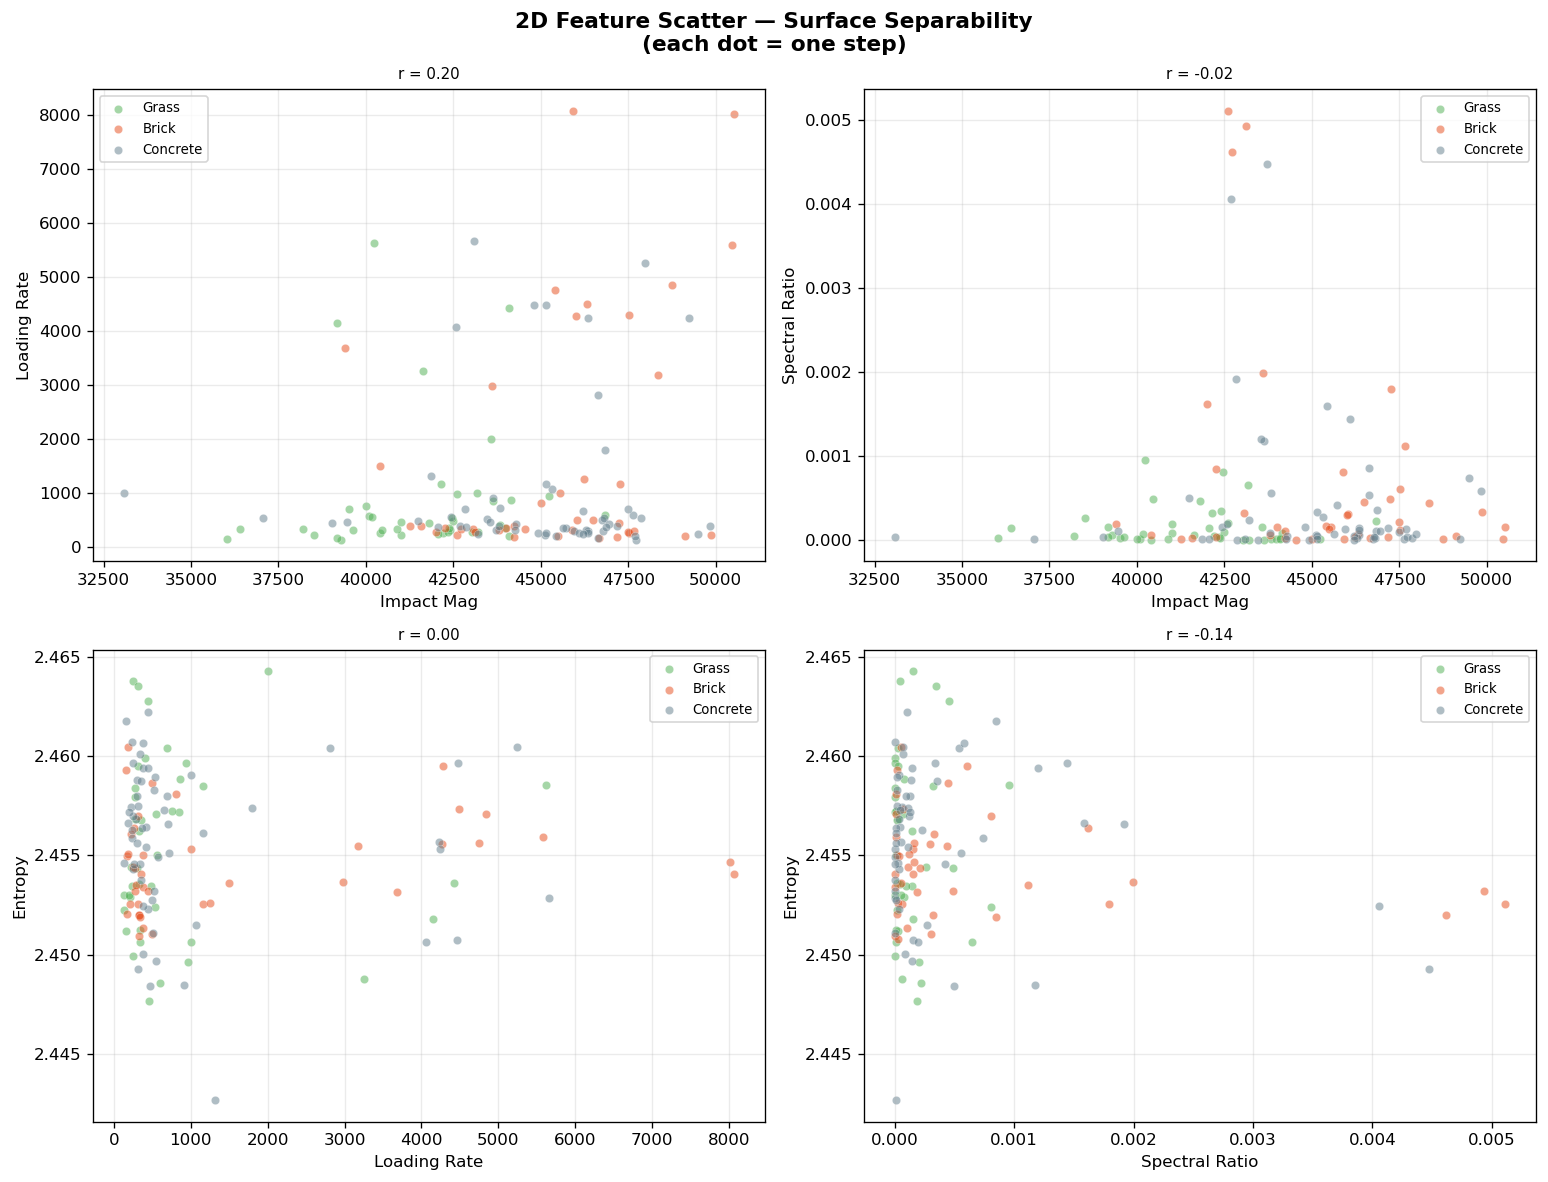

Saved → feature_scatter.png


In [14]:
pairs = [
    ('impact_magnitude',      'loading_rate',          'Impact Mag', 'Loading Rate'),
    ('impact_magnitude',      'spectral_energy_ratio', 'Impact Mag', 'Spectral Ratio'),
    ('loading_rate',          'pressure_entropy',      'Loading Rate', 'Entropy'),
    ('spectral_energy_ratio', 'pressure_entropy',      'Spectral Ratio', 'Entropy'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('2D Feature Scatter — Surface Separability\n(each dot = one step)',
             fontsize=13, fontweight='bold')

for ax, (xc, yc, xl, yl) in zip(axes.flat, pairs):
    for s in surfaces_ord:
        sub = features_df[features_df['surface'] == s]
        ax.scatter(sub[xc], sub[yc],
                   color=SURFACE_COLORS[s], alpha=0.5, s=25,
                   edgecolors='white', linewidths=0.3,
                   label=s.capitalize())

    r = features_df[xc].corr(features_df[yc])
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f'r = {r:.2f}', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('feature_scatter.png', bbox_inches='tight')
plt.show()
print('Saved → feature_scatter.png')

## 14. Summary

### What was built

| Step | Output |
|------|--------|
| Segmentation | Deep-valley detection on smoothed total pressure → step boundaries |
| Feature 1 | `impact_magnitude` — peak |accel_y| at heel strike |
| Feature 2 | `loading_rate` — heel pressure rise rate (ADC/s) |
| Feature 3 | `spectral_energy_ratio` — FFT high/low frequency ratio |
| Feature 4 | `pressure_entropy` — 12-zone distribution Shannon entropy |
| Feature 5 | `step_duration` — step timing |
| Feature 6 | `*_var` — rolling std across 4 consecutive steps (meta-feature) |
| Export | `step_features_per_step.csv`, `step_features_trial_level.csv` |

### Recommended next steps

1. **Random Forest classifier** — use `step_features_per_step.csv` with `surface` as label
2. **Feature importance plot** — which features drive the most discrimination?
3. **Cross-validation** — leave-one-trial-out or stratified k-fold
4. **Add more surfaces** — gravel, carpet, sand for richer training data
5. **Tune segmentation** — validate step counts against video if available